### Improving performance

#### 一,错误分析
- 手动查看错误案例：查看 100 个左右模型预测错误的例子
- 定位“热点”问题：如果你发现 70% 的错误都来自某个特定类别（比如戴帽子的人脸），那么针对性地获取这部分数据，比盲目增加百万量级的数据要高效得多

#### 二,数据驱动
- 数据增强（Data Augmentation）：利用旋转、裁剪、添加噪声等手段，强制模型学习更具鲁棒性的特征
- 处理类别不平衡：如果正负样本比例超过 1:10，模型可能会倾向于预测出现频率更高的类别.你可以通过复制正样本或在损失函数中增加权重来平衡它
- 提升特征提取质量：比如在视觉任务中，挑选出清晰、对焦准的帧（High Resolution Frames）作为输入，能显著提升识别精度

#### 三.模型容量与超参数调试
- 增加模型容量：如果模型在训练集上表现很差（欠拟合），说明你需要更深的网络或更多的参数来捕捉复杂特征
- 正则化与 Dropout：如果模型在训练集完美但在验证集很差（过拟合），就需要使用正则化或 Dropout 
- 超参数调参：学习率、网络大小、优化器选择等超参数需要不断试验，这往往是决定模型能否收敛的关键

#### 采用上个lecture的案例

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用设备:", device)

使用设备: cuda


In [3]:
# 数据增强
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4), #随机裁剪
    transforms.RandomHorizontalFlip(),    #随机水平翻转
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
]) #归一化

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

train_set = datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_train)
test_set = datasets.CIFAR10(root='./data', train=False, download=False, transform=transform_test)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

classes = ['飞机', '汽车', '鸟', '猫', '鹿', '狗', '青蛙', '马', '船', '卡车']

In [4]:
#CNN,添加droupout
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(-1, 128 * 4 * 4)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = CNN().to(device)

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) #权重衰退
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [8]:
epochs = 20
train_acc_list = []
test_acc_list = []
train_loss_list = []
test_loss_list = []

for epoch in range(epochs):
    model.train()
    correct, total = 0, 0
    total_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total
    train_loss = total_loss / len(train_loader)

    model.eval()
    correct, total = 0, 0
    total_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = correct / total
    test_loss = total_loss / len(test_loader)

    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)

    scheduler.step()

    print(f"[{epoch+1}/{epochs}] 训练Loss: {train_loss:.3f} | 测试Loss: {test_loss:.3f} | 训练Acc: {train_acc:.2f} | 测试Acc: {test_acc:.2f}")

[1/20] 训练Loss: 1.652 | 测试Loss: 1.364 | 训练Acc: 0.39 | 测试Acc: 0.49
[2/20] 训练Loss: 1.370 | 测试Loss: 1.098 | 训练Acc: 0.50 | 测试Acc: 0.60
[3/20] 训练Loss: 1.181 | 测试Loss: 0.957 | 训练Acc: 0.58 | 测试Acc: 0.66
[4/20] 训练Loss: 1.058 | 测试Loss: 0.876 | 训练Acc: 0.63 | 测试Acc: 0.69
[5/20] 训练Loss: 0.983 | 测试Loss: 0.805 | 训练Acc: 0.66 | 测试Acc: 0.72
[6/20] 训练Loss: 0.872 | 测试Loss: 0.764 | 训练Acc: 0.70 | 测试Acc: 0.73
[7/20] 训练Loss: 0.831 | 测试Loss: 0.735 | 训练Acc: 0.71 | 测试Acc: 0.74
[8/20] 训练Loss: 0.805 | 测试Loss: 0.686 | 训练Acc: 0.72 | 测试Acc: 0.76
[9/20] 训练Loss: 0.776 | 测试Loss: 0.656 | 训练Acc: 0.73 | 测试Acc: 0.77
[10/20] 训练Loss: 0.753 | 测试Loss: 0.645 | 训练Acc: 0.74 | 测试Acc: 0.78
[11/20] 训练Loss: 0.706 | 测试Loss: 0.619 | 训练Acc: 0.76 | 测试Acc: 0.79
[12/20] 训练Loss: 0.685 | 测试Loss: 0.609 | 训练Acc: 0.76 | 测试Acc: 0.79
[13/20] 训练Loss: 0.672 | 测试Loss: 0.614 | 训练Acc: 0.77 | 测试Acc: 0.79
[14/20] 训练Loss: 0.662 | 测试Loss: 0.597 | 训练Acc: 0.77 | 测试Acc: 0.79
[15/20] 训练Loss: 0.649 | 测试Loss: 0.602 | 训练Acc: 0.78 | 测试Acc: 0.79
[16/20] 训练Loss: 0.6

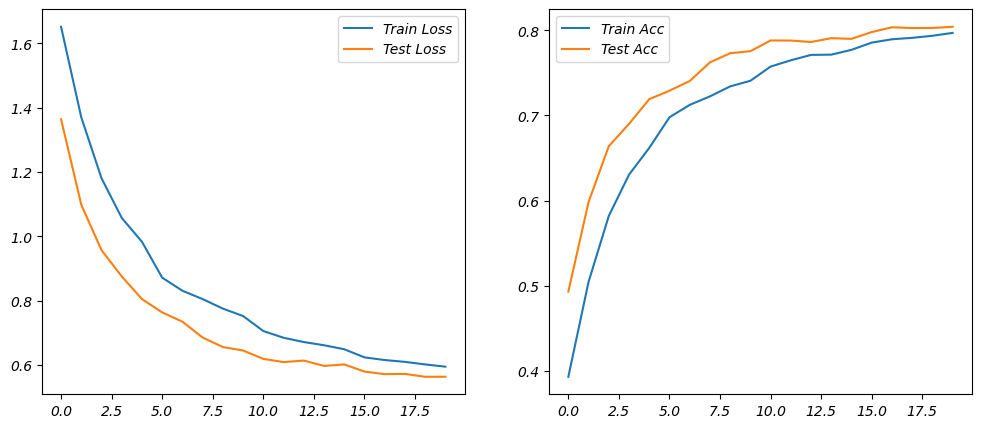

In [9]:
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(test_loss_list, label='Test Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_acc_list, label='Train Acc')
plt.plot(test_acc_list, label='Test Acc')
plt.legend()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4182549..2.3245049].


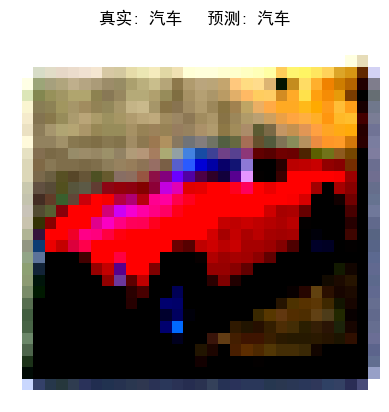

In [14]:
#预测
def predict(img):
    model.eval()
    img = img.unsqueeze(0).to(device)
    output = model(img)
    return classes[torch.argmax(output).item()]

# 随机测试一张
idx = 1234
img, label = test_set[idx]
pred = predict(img)
true = classes[label]

plt.imshow(img.permute(1, 2, 0))
plt.title(f"真实: {true}   预测: {pred}")
plt.axis('off')
plt.show()